# 语义分割数据集可视化探索

## 1. 环境准备与全局设置

本节负责导入所有的依赖库、锁定绝对工作路径，并配置好能无视缓存强行生效的中文字体，确保后续的可视化不出现乱码。

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 锁定绝对工作目录
WORK_DIR = '/root/LearningMMSegmentation/mmsegmentation'
if os.path.exists(WORK_DIR):
    os.chdir(WORK_DIR)
else:
    print(f"❌ 工作目录不存在，请检查: {WORK_DIR}")

# 2. 挂载中文字体 (跳过缓存直接读取)
FONT_PATH = '/root/LearningMMSegmentation/SimHei.ttf'
if not os.path.exists(FONT_PATH):
    # 如果字体不存在，自动下载
    os.system(f'wget -q https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf -O {FONT_PATH}')
my_font = fm.FontProperties(fname=FONT_PATH, size=14)

print(f"✅ 环境初始化完成！当前工作路径: {os.getcwd()}")

✅ 环境初始化完成！当前工作路径: /root/LearningMMSegmentation/mmsegmentation


## 2. 加载语义分割类别与调色板
读取记录了类别信息的 `CSV` 文件，建立“类别ID”到“显示颜色”的映射字典，供后续上色使用。

In [2]:
# 读取西瓜数据集的类别信息表
classes_file = 'D.watermelon_classes.csv'
df = pd.read_csv(classes_file)

# 创建映射字典：类别 ID (0,1,2...) -> 对应的颜色 (B,G,R)
# 注意：OpenCV 默认色彩空间为 BGR
palette_dict = {}
for idx, row in df.iterrows():
    palette_dict[idx] = [row['r'], row['g'], row['b']]

print(f"✅ 成功加载调色板！共 {len(palette_dict)} 个类别。")

✅ 成功加载调色板！共 6 个类别。


## 3. 核心可视化逻辑封装

**说明**：将“读取、匹配颜色、融合、画图”这套核心动作**封装成了一个通用函数**。
后续无论是画 1 张图还是 100 张图，只需调用 **draw_segmentation_overlay** 即可，代码极其整洁。

In [3]:
def draw_segmentation_overlay(img_path, mask_path, palette, opacity=0.2, axes=None, title=""):
    """
    通用语义分割可视化函数。
    参数:
        img_path: 原图路径
        mask_path: 标注图(掩码)路径
        palette: 调色板字典
        opacity: 掩码透明度
        axes: 传入的 matplotlib 子图对象数组 (包含左图和右图)
        title: 图片标题前缀
    """
    # 1. 容错读取
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) # 单通道读取
    if img is None or mask is None:
        print(f"❌ 读取失败: {img_path} 或对应标注不存在。")
        return

    # 2. 根据调色板为掩码进行染色
    viz_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls_id, color in palette.items():
        viz_mask[mask == cls_id] = color
        
    # 3. 按透明度融合图像 (img和viz_mask均为BGR格式)
    overlay_img = cv2.addWeighted(img, opacity, viz_mask, 1 - opacity, 0)

    # 4. 色彩空间转换 (供 Matplotlib 显示使用)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay_rgb = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)

    # 5. 渲染图像
    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # 单图模式新建画板

    axes[0].imshow(img_rgb)
    axes[0].set_title(f"原图: {title}", fontproperties=my_font)
    axes[0].axis('off')

    axes[1].imshow(overlay_rgb)
    axes[1].set_title(f"标注叠加 (透明度: {opacity})", fontproperties=my_font)
    axes[1].axis('off')
    
    if axes is None:
        plt.show() # 如果是单图调用，直接在此处显示

## 4. 语义分割数据集可视化探索

### 任务 A：指定单张图像可视化

指定图片具体路径

In [4]:
print("▶️ 开始单张图像可视化：")
single_img = 'data/Watermelon87_Semantic_Seg_Mask/img_dir/train/045_sozai_l.jpg'
single_mask = 'data/Watermelon87_Semantic_Seg_Mask/ann_dir/train/045_sozai_l.png'

▶️ 开始单张图像可视化：


单张图片语义分割可视化展示

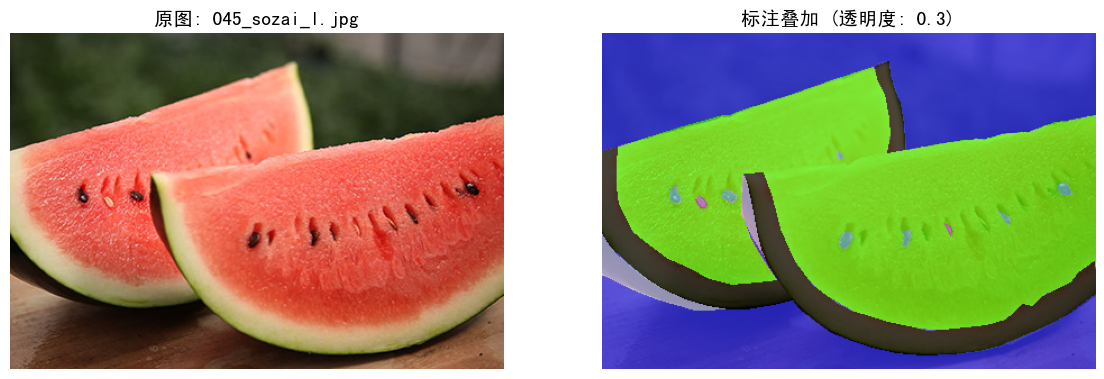

In [5]:
draw_segmentation_overlay(single_img, single_mask, palette_dict, opacity=0.3, title="045_sozai_l.jpg")

### 任务 B：批量随机图像可视化

指定批量处理图片路径

In [6]:
print("\n▶️ 开始批量图像可视化：")
PATH_IMAGES = 'data/Watermelon87_Semantic_Seg_Mask/img_dir/train'
PATH_MASKS = 'data/Watermelon87_Semantic_Seg_Mask/ann_dir/train'
N_SAMPLES = 4  # 抽取数量


▶️ 开始批量图像可视化：


严格过滤有效后缀

In [7]:
valid_files = [f for f in os.listdir(PATH_IMAGES) if f.lower().endswith(('.jpg', '.png'))]
selected_files = random.sample(valid_files, min(N_SAMPLES, len(valid_files)))

创建批量网格画板 (N行 x 2列)。遍历图片并调用绘图函数

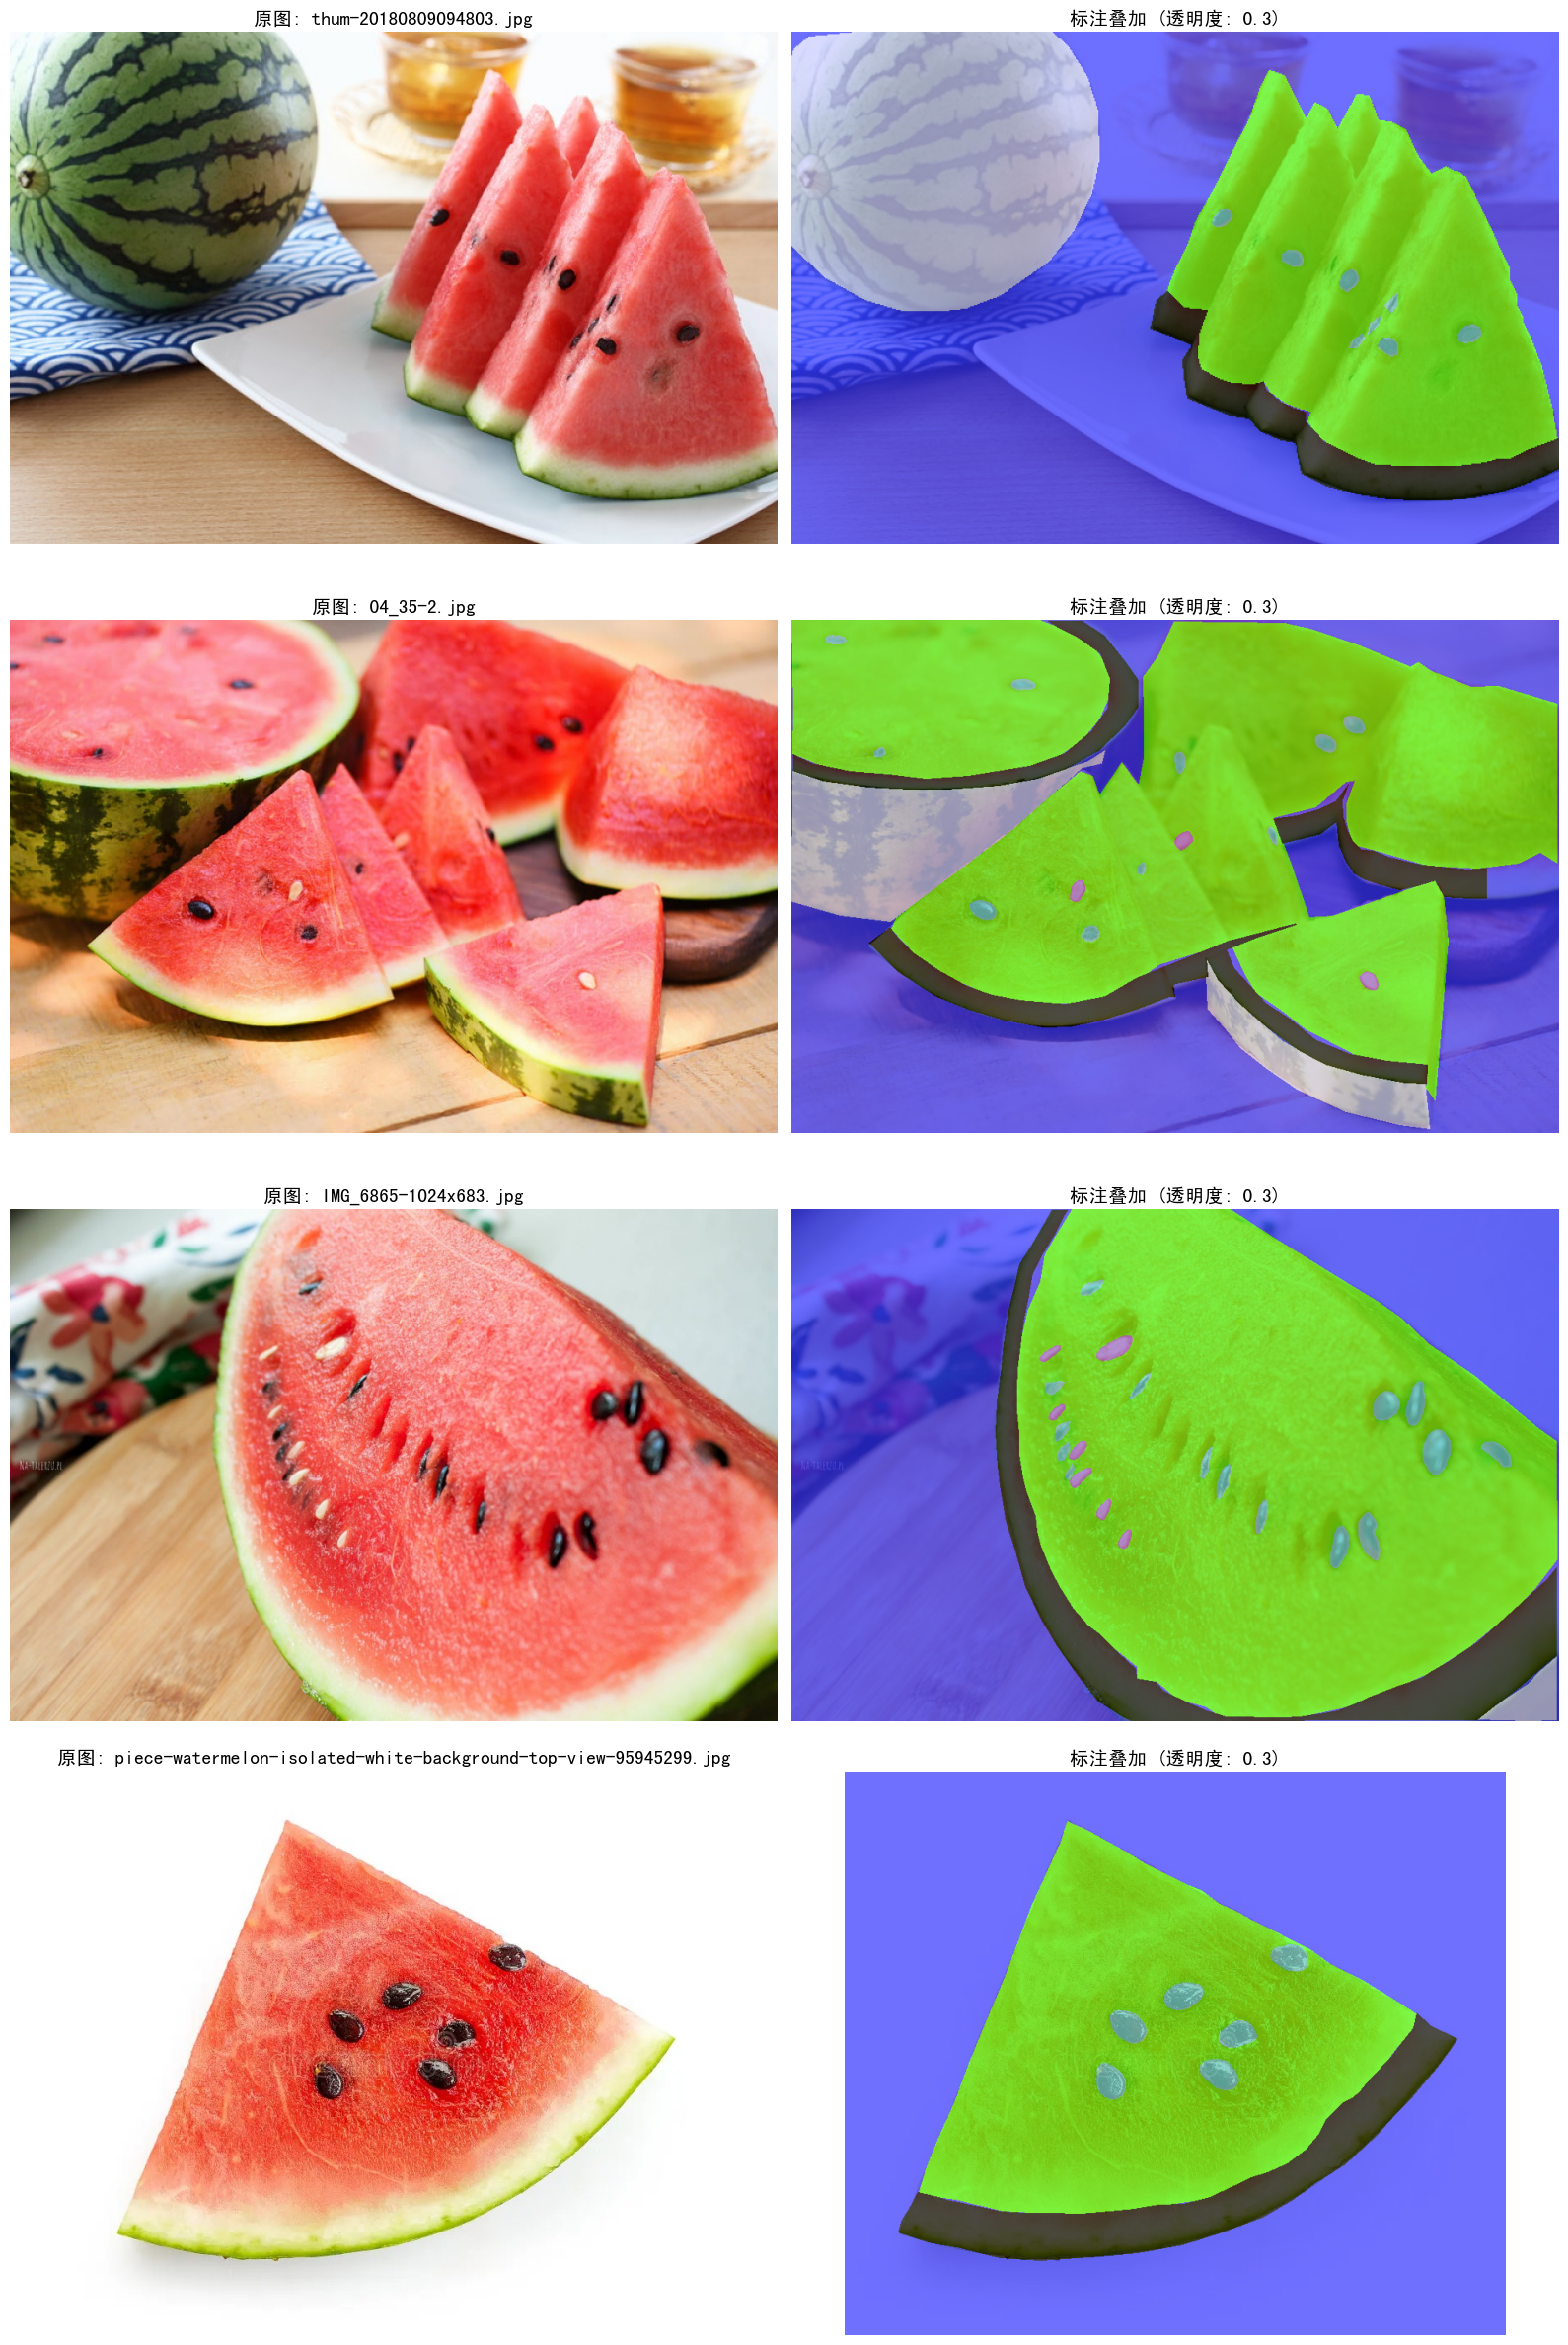

In [8]:
# 创建网格画板
fig, axes_grid = plt.subplots(nrows=len(selected_files), ncols=2, figsize=(16, 6 * len(selected_files)))

#遍历图片并绘图
for i, file_name in enumerate(selected_files):
    img_path = os.path.join(PATH_IMAGES, file_name)
    mask_path = os.path.join(PATH_MASKS, file_name.replace('.jpg', '.png'))
    
    # 提取当前行的两个子图位 (axes_grid[i]) 传给函数
    draw_segmentation_overlay(img_path, mask_path, palette_dict, opacity=0.3, axes=axes_grid[i], title=file_name)

plt.tight_layout()
plt.show()